In [18]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler

In [5]:
import seaborn as sns  #to get colors
sns.set()
from sklearn.cluster import KMeans

In [11]:
raw_data=pd.read_csv("Countries.csv")

In [12]:
raw_data

,name,Longitude,Latitude
0,Aruba,-69.982677,12.520880
1,Afghanistan,66.004734,33.835231
2,Angola,17.537368,-12.293361
3,Anguilla,-63.064989,18.223959
4,Albania,20.049834,41.142450
...,...,...,...
236,Samoa,-172.164851,-13.753243
237,Yemen,47.586762,15.909280
238,South Africa,25.083901,-29.000341
239,Zambia,27.774759,-13.458242


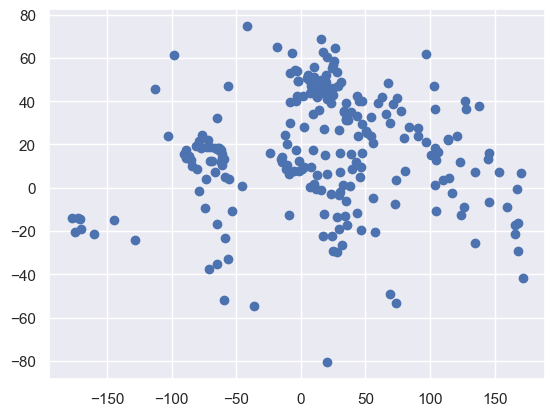

In [14]:
plt.scatter(raw_data['Longitude'],raw_data['Latitude'])

In [15]:
cluster_data=raw_data.iloc[:,[1,2]] #create new datframe

In [16]:
cluster_data.head()

,Longitude,Latitude
0,-69.982677,12.520880
1,66.004734,33.835231
2,17.537368,-12.293361
3,-63.064989,18.223959
4,20.049834,41.142450


In [21]:
#Standardization
ss = StandardScaler() 
cluster_data = pd.DataFrame(ss.fit_transform(cluster_data), columns=['Longitude', 'Latitude'])

In [22]:
cluster_data.head()

,Longitude,Latitude
0,-1.171629,-0.175422
1,0.720657,0.628927
2,0.046226,-1.111849
3,-1.075368,0.039797
4,0.081187,0.904683


In [24]:
#clusteirng
kmeans = KMeans(4)  #model creation : kmeans is a model name can any name

In [25]:
kmeans.fit(cluster_data)  #cluster_data train (use fit to train) using kmeans model

C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

KMeans(n_clusters=4)

In [26]:
identified_clusters = kmeans.fit_predict(cluster_data)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
identified_clusters

array([1, 0, 3, 1, 0, 0, 0, 0, 1, 0, 1, 3, 2, 3, 1, 2, 0, 0, 3, 0, 3, 3,
       2, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 2, 3, 3, 0, 1, 0, 3, 3,
       3, 3, 1, 1, 3, 1, 1, 1, 1, 1, 0, 0, 0, 0, 3, 1, 0, 1, 0, 1, 0, 3,
       0, 0, 3, 0, 2, 3, 0, 0, 2, 3, 0, 0, 0, 3, 3, 3, 3, 3, 0, 1, 0, 1,
       2, 1, 2, 3, 1, 0, 1, 0, 2, 0, 2, 2, 3, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       2, 0, 0, 3, 0, 2, 1, 1, 2, 0, 0, 2, 0, 3, 0, 1, 0, 2, 3, 0, 0, 0,
       2, 1, 0, 0, 0, 3, 2, 1, 2, 0, 3, 0, 2, 0, 0, 2, 3, 0, 1, 3, 3, 2,
       3, 2, 3, 2, 3, 1, 1, 0, 0, 0, 2, 2, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1,
       2, 0, 1, 0, 1, 0, 0, 0, 3, 0, 0, 3, 3, 3, 2, 3, 3, 2, 3, 1, 0, 3,
       3, 0, 0, 3, 1, 0, 0, 0, 3, 1, 3, 0, 1, 3, 3, 2, 0, 0, 2, 1, 1, 0,
       0, 2, 3, 3, 0, 3, 1, 0, 0, 1, 1, 1, 1, 2, 2, 1, 1, 3, 3, 3, 3],
      dtype=int32)

In [29]:
new_data = raw_data.copy()  #create copy of raw data

In [30]:
new_data.head()

,name,Longitude,Latitude
0,Aruba,-69.982677,12.520880
1,Afghanistan,66.004734,33.835231
2,Angola,17.537368,-12.293361
3,Anguilla,-63.064989,18.223959
4,Albania,20.049834,41.142450


In [33]:
new_data ['ClusterNo']=identified_clusters  #add new coloumn name cluster number

In [34]:
new_data.head()

,name,Longitude,Latitude,ClusterNo
0,Aruba,-69.982677,12.520880,1
1,Afghanistan,66.004734,33.835231,0
2,Angola,17.537368,-12.293361,3
3,Anguilla,-63.064989,18.223959,1
4,Albania,20.049834,41.142450,0


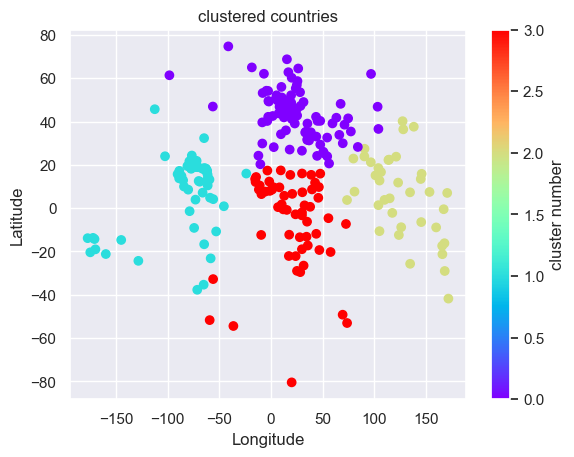

In [36]:
plt.scatter(new_data['Longitude'],new_data['Latitude'], c=new_data['ClusterNo'], cmap = 'rainbow')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('clustered countries')
plt.colorbar(label = 'cluster number')
plt.show()

In [38]:
wcss=[] 
for i in range(1,11): 
    kmeans = KMeans(i) 
    kmeans.fit(cluster_data) 
    wcss_iter = kmeans.inertia_ 
    wcss.append(wcss_iter)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [39]:
wcss

[481.99999999999994,
 304.03529335762437,
 182.71616222885794,
 140.72852430229963,
 111.47228446042108,
 88.48075009465327,
 76.12297634291217,
 61.996460767420004,
 51.8766741409151,
 50.15112171469591]

Text(0, 0.5, 'Within-cluster Sum of Squares')

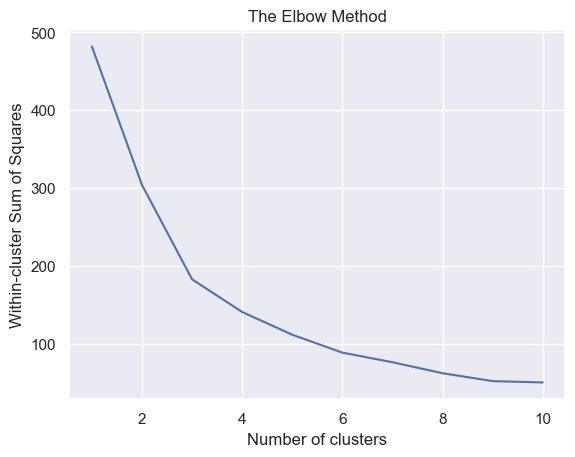

In [42]:
number_clusters = range(1,11)
plt.plot(number_clusters,wcss) 
plt.title('The Elbow Method') 
plt.xlabel('Number of clusters') 
plt.ylabel('Within-cluster Sum of Squares')